# 🩺 Chronic Kidney Disease Prediction: ML for Renal Health Screening

**Author:** Dean | Lead Data & AI Engineer  
**Focus:** Predicting chronic kidney disease from clinical pathology to support early detection and nephrology referral  
**Series:** Production ML Portfolio — Australian Government Policy Applications

---

## Executive Summary

This notebook demonstrates a production-grade ML pipeline for predicting chronic kidney disease (CKD) using blood and urine pathology results, blood pressure, and clinical indicators. The model supports **population-level CKD screening** and **GP decision support** for timely nephrology referral.

### Government Policy Context
- **Department of Health & Aged Care** — Kidney Health Australia partnership, CKD National Action Plan
- **AIHW** — CKD surveillance, burden of disease reporting, dialysis/transplant registry
- **PBS** — Renal medication utilisation (ACE inhibitors, ARBs, EPO), cost-effectiveness
- **Medicare** — Chronic Disease Management items (721/723), kidney health assessments
- **Kidney Health Australia** — CKD risk screening, Know Your Kidneys campaign

### Clinical Decision Framework
| Prediction | Action | Stakeholder |
|-----------|--------|-------------|
| High CKD risk | Urgent nephrology referral, eGFR/ACR pathology | GP + nephrologist |
| Moderate risk | Renal function monitoring, BP/diabetes management | GP + practice nurse |
| Low risk (confident) | Annual kidney health check with routine bloods | Automated recall |
| Low risk (diabetes/hypertension) | Enhanced renal monitoring every 6 months | Chronic disease nurse |

---


## 1. Data Loading & Initial Assessment

In [1]:
import os, warnings, time
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import StratifiedKFold
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import (accuracy_score, f1_score, classification_report,
                             confusion_matrix, roc_auc_score, precision_score,
                             recall_score, brier_score_loss)
from sklearn.calibration import calibration_curve
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
warnings.filterwarnings('ignore')
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
print("=" * 60)
print("ENVIRONMENT READY")
print("=" * 60)


ENVIRONMENT READY


In [2]:
data_path = None
for root, dirs, files in os.walk('/kaggle/input'):
    for f in files:
        full_path = os.path.join(root, f)
        print(f"  Found: {full_path}")
        if f.endswith('.csv') and data_path is None:
            data_path = full_path

if data_path is None:
    raise FileNotFoundError("No CSV found")

df = pd.read_csv(data_path)
print(f"\nUsing: {data_path}")
print(f"Loaded: {df.shape[0]:,} rows x {df.shape[1]} columns")


  Found: /kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv

Using: /kaggle/input/datasets/mansoordaku/ckdisease/kidney_disease.csv
Loaded: 400 rows x 26 columns


In [3]:
print("COLUMN SUMMARY")
print("=" * 80)
for i, col in enumerate(df.columns):
    dtype = df[col].dtype
    nuniq = df[col].nunique()
    nulls = df[col].isnull().sum()
    null_pct = f" ({nulls/len(df)*100:.1f}%)" if nulls > 0 else ""
    sample_val = df[col].dropna().iloc[0] if len(df[col].dropna()) > 0 else 'N/A'
    print(f"  {i:2d}. {col:25s} | {str(dtype):10s} | unique={nuniq:5d} | nulls={nulls}{null_pct}")
df.head()


COLUMN SUMMARY
   0. id                        | int64      | unique=  400 | nulls=0
   1. age                       | float64    | unique=   76 | nulls=9 (2.2%)
   2. bp                        | float64    | unique=   10 | nulls=12 (3.0%)
   3. sg                        | float64    | unique=    5 | nulls=47 (11.8%)
   4. al                        | float64    | unique=    6 | nulls=46 (11.5%)
   5. su                        | float64    | unique=    6 | nulls=49 (12.2%)
   6. rbc                       | object     | unique=    2 | nulls=152 (38.0%)
   7. pc                        | object     | unique=    2 | nulls=65 (16.2%)
   8. pcc                       | object     | unique=    2 | nulls=4 (1.0%)
   9. ba                        | object     | unique=    2 | nulls=4 (1.0%)
  10. bgr                       | float64    | unique=  146 | nulls=44 (11.0%)
  11. bu                        | float64    | unique=  118 | nulls=19 (4.8%)
  12. sc                        | float64    | unique

,id,age,bp,sg,al,su,rbc,pc,pcc,ba,...,pcv,wc,rc,htn,dm,cad,appet,pe,ane,classification
0,0,48.0,80.0,1.020,1.0,0.0,NaN,normal,notpresent,notpresent,...,44,7800,5.2,yes,yes,no,good,no,no,ckd
1,1,7.0,50.0,1.020,4.0,0.0,NaN,normal,notpresent,notpresent,...,38,6000,NaN,no,no,no,good,no,no,ckd
2,2,62.0,80.0,1.010,2.0,3.0,normal,normal,notpresent,notpresent,...,31,7500,NaN,no,yes,no,poor,no,yes,ckd
3,3,48.0,70.0,1.005,4.0,0.0,normal,abnormal,present,notpresent,...,32,6700,3.9,yes,no,no,poor,yes,yes,ckd
4,4,51.0,80.0,1.010,2.0,0.0,normal,normal,notpresent,notpresent,...,35,7300,4.6,no,no,no,good,no,no,ckd


## 2. Target Variable Analysis

In [4]:
# Known target for CKD dataset: 'classification' or 'class'
target_candidates = ['classification', 'class', 'Class', 'ckd', 'CKD', 'Target', 'target',
                     'Label', 'label', 'Outcome', 'outcome']
target_col = None
for candidate in target_candidates:
    if candidate in df.columns:
        target_col = candidate
        print(f"Found target: '{target_col}'")
        break

if target_col is None:
    last_col = df.columns[-1]
    if df[last_col].nunique() <= 10:
        target_col = last_col
        print(f"Fallback: '{target_col}'")

if target_col is None:
    raise ValueError("Could not identify target")

print(f"\nRaw values:")
print(df[target_col].value_counts())

# Clean and encode target
if df[target_col].dtype == 'object':
    # Clean whitespace/tabs
    df[target_col] = df[target_col].str.strip()
    # Map: ckd=1, notckd=0 (or similar)
    unique_vals = df[target_col].unique().tolist()
    print(f"Unique values: {unique_vals}")
    ckd_keywords = ['ckd', 'CKD', 'yes', 'Yes', 'Y', '1', 'positive', 'Positive']
    mapping = {}
    for v in unique_vals:
        if str(v).strip() in ckd_keywords:
            mapping[v] = 1
        else:
            mapping[v] = 0
    df[target_col] = df[target_col].map(mapping)
    print(f"Mapped: {mapping}")

# Drop any NaN in target
df = df.dropna(subset=[target_col]).reset_index(drop=True)
df[target_col] = df[target_col].astype(int)

print(f"\nDistribution:")
print(df[target_col].value_counts().sort_index())
assert df[target_col].nunique() >= 2
imbalance_ratio = df[target_col].value_counts().min() / df[target_col].value_counts().max()
print(f"\nImbalance ratio: {imbalance_ratio:.3f}")


Found target: 'classification'

Raw values:
classification
ckd       248
notckd    150
ckd\t       2
Name: count, dtype: int64
Unique values: ['ckd', 'notckd']
Mapped: {'ckd': 1, 'notckd': 0}

Distribution:
classification
0    150
1    250
Name: count, dtype: int64

Imbalance ratio: 0.600


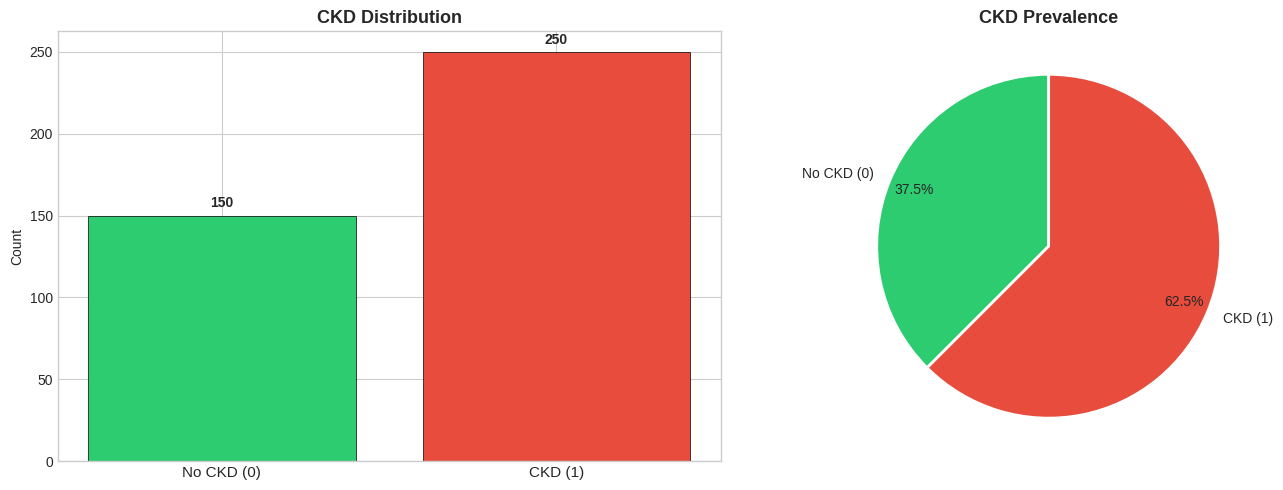

AU context: ~1.7M Australians have CKD. Leading cause of kidney failure requiring dialysis.
Indigenous Australians are 3.5x more likely to have CKD (AIHW).
Early detection can slow progression by 50%+ with appropriate management.


In [5]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
vc = df[target_col].value_counts().sort_index()
labels = ['No CKD (0)', 'CKD (1)']
colors = ['#2ecc71', '#e74c3c']
axes[0].bar(range(2), vc.values, color=colors, edgecolor='black', linewidth=0.5)
axes[0].set_xticks(range(2)); axes[0].set_xticklabels(labels, fontsize=11)
axes[0].set_title('CKD Distribution', fontsize=13, fontweight='bold')
axes[0].set_ylabel('Count')
for i, v in enumerate(vc.values):
    axes[0].text(i, v + 5, str(v), ha='center', fontweight='bold')
axes[1].pie(vc.values, labels=labels, autopct='%1.1f%%', colors=colors,
            startangle=90, pctdistance=0.85, wedgeprops={'edgecolor': 'white', 'linewidth': 2})
axes[1].set_title('CKD Prevalence', fontsize=13, fontweight='bold')
plt.tight_layout(); plt.savefig('target_distribution.png', dpi=150, bbox_inches='tight'); plt.show()
print("AU context: ~1.7M Australians have CKD. Leading cause of kidney failure requiring dialysis.")
print("Indigenous Australians are 3.5x more likely to have CKD (AIHW).")
print("Early detection can slow progression by 50%+ with appropriate management.")


## 3. Exploratory Data Analysis

Key clinical questions:
- Which pathology results best predict CKD (serum creatinine, albumin, haemoglobin)?
- Does blood pressure correlate with kidney disease?
- Are there diabetes/hypertension comorbidity patterns?
- How do red/white blood cell counts relate to CKD?


Numeric features (14): ['age', 'bp', 'sg', 'al', 'su', 'bgr', 'bu', 'sc', 'sod', 'pot', 'hemo', 'pcv', 'wc', 'rc']


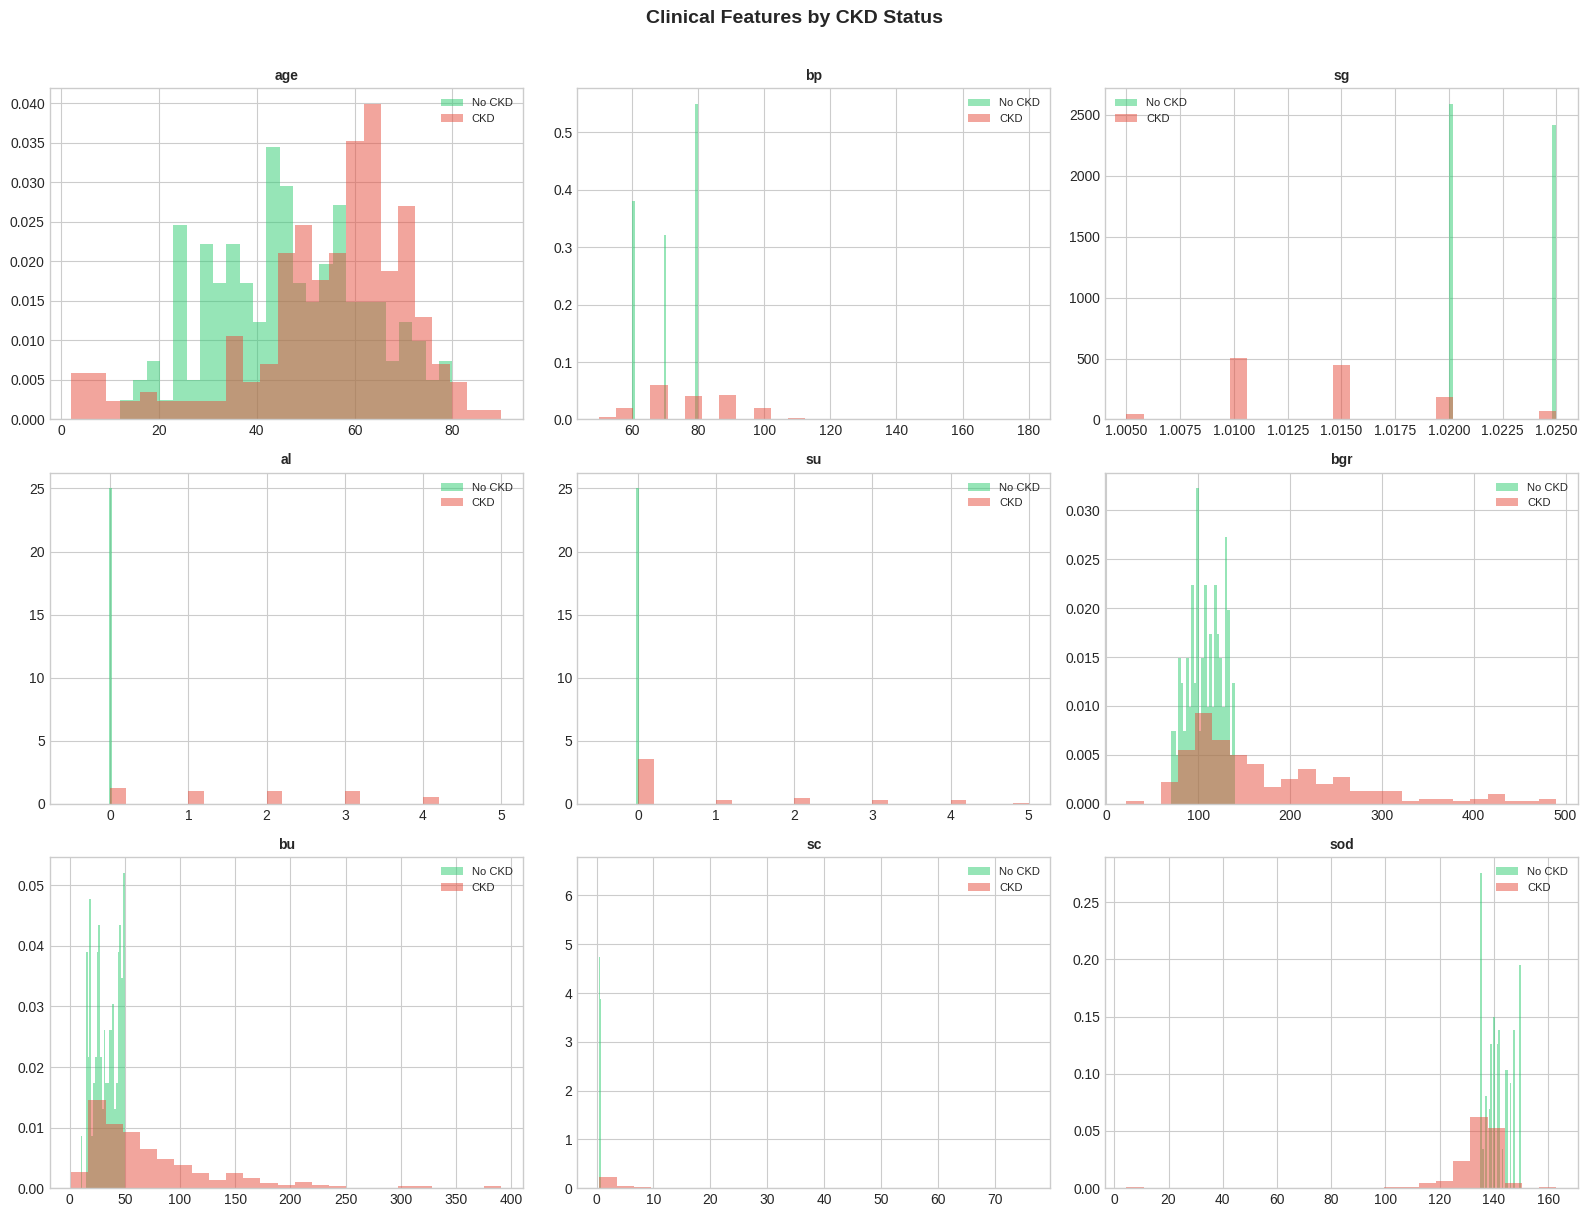

In [6]:
# Convert numeric columns that may be stored as strings
for col in df.columns:
    if col != target_col and df[col].dtype == 'object':
        # Try numeric conversion
        df[col] = df[col].str.strip() if df[col].dtype == 'object' else df[col]
        try:
            converted = pd.to_numeric(df[col], errors='coerce')
            if converted.notna().sum() > len(df) * 0.5:
                df[col] = converted
        except:
            pass

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
if target_col in numeric_cols: numeric_cols.remove(target_col)
numeric_cols = [c for c in numeric_cols if c.lower() not in ['id', 'index']]
print(f"Numeric features ({len(numeric_cols)}): {numeric_cols}")

plot_cols = numeric_cols[:9]
if len(plot_cols) > 0:
    n_rows_p = (len(plot_cols) + 2) // 3
    fig, axes = plt.subplots(n_rows_p, 3, figsize=(16, 4 * n_rows_p))
    axes = axes.flatten()
    for i, col in enumerate(plot_cols):
        for label, color, name in zip([0, 1], ['#2ecc71', '#e74c3c'], ['No CKD', 'CKD']):
            subset = df[df[target_col] == label][col].dropna()
            if len(subset) > 0:
                axes[i].hist(subset, bins=25, alpha=0.5, label=name, density=True, color=color)
        axes[i].set_title(col, fontsize=10, fontweight='bold'); axes[i].legend(fontsize=8)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.suptitle('Clinical Features by CKD Status', fontsize=14, fontweight='bold', y=1.01)
    plt.tight_layout(); plt.savefig('feature_distributions.png', dpi=150, bbox_inches='tight'); plt.show()


Categorical features: ['rbc', 'pc', 'pcc', 'ba', 'htn', 'dm', 'cad', 'appet', 'pe', 'ane']


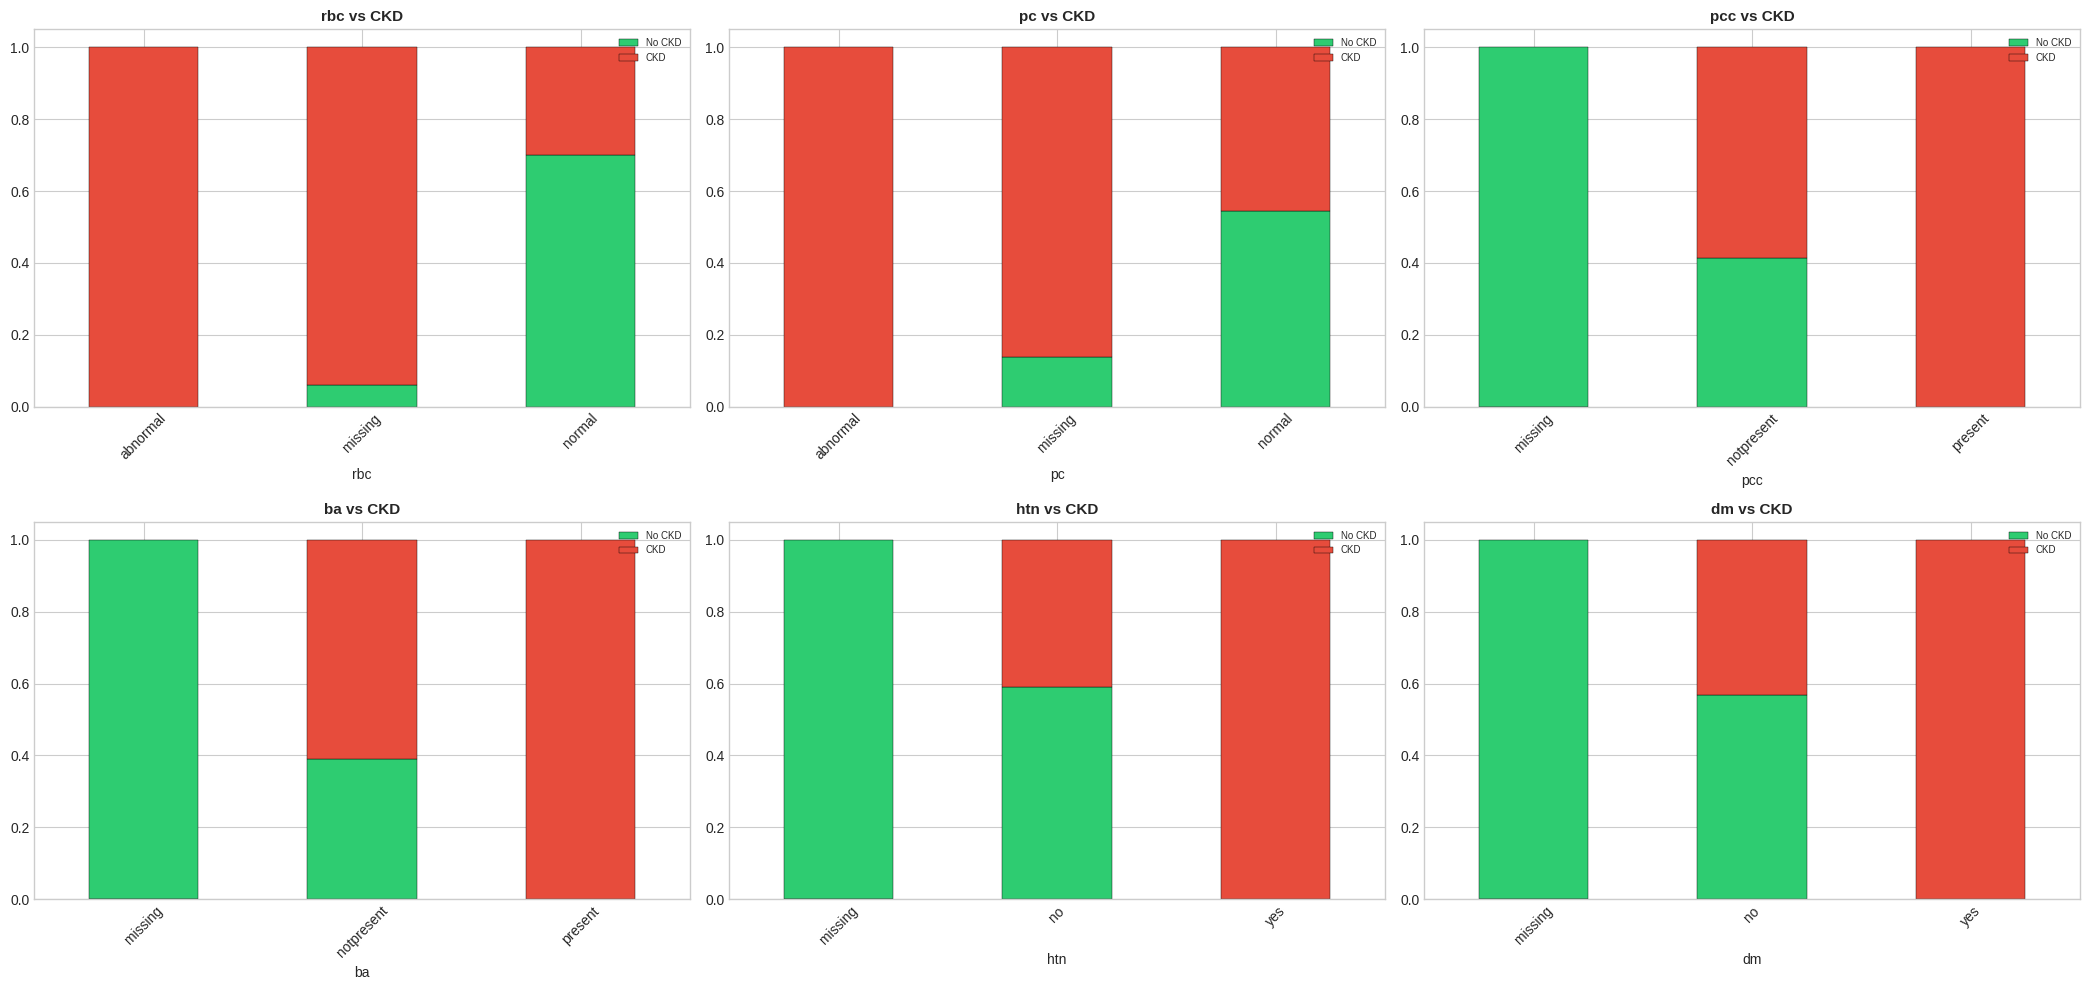

In [7]:
cat_cols = df.select_dtypes(include=['object']).columns.tolist()
if target_col in cat_cols: cat_cols.remove(target_col)
cat_cols = [c for c in cat_cols if df[c].nunique() <= 10]
print(f"Categorical features: {cat_cols}")

if len(cat_cols) > 0:
    plot_cats = cat_cols[:6]
    n_cols_p = min(3, len(plot_cats))
    n_rows_p = (len(plot_cats) + n_cols_p - 1) // n_cols_p
    fig, axes = plt.subplots(n_rows_p, n_cols_p, figsize=(7 * n_cols_p, 5 * n_rows_p))
    if isinstance(axes, np.ndarray): axes = axes.flatten()
    else: axes = [axes]
    for i, col in enumerate(plot_cats):
        df[col] = df[col].str.strip() if df[col].dtype == 'object' else df[col]
        ct = pd.crosstab(df[col].fillna('missing'), df[target_col], normalize='index')
        ct.plot(kind='bar', stacked=True, ax=axes[i], color=['#2ecc71', '#e74c3c'],
                edgecolor='black', linewidth=0.3)
        axes[i].set_title(f'{col} vs CKD', fontsize=11, fontweight='bold')
        axes[i].tick_params(axis='x', rotation=45)
        axes[i].legend(['No CKD', 'CKD'], fontsize=7)
    for j in range(i + 1, len(axes)):
        axes[j].set_visible(False)
    plt.tight_layout(); plt.savefig('categorical_analysis.png', dpi=150, bbox_inches='tight'); plt.show()


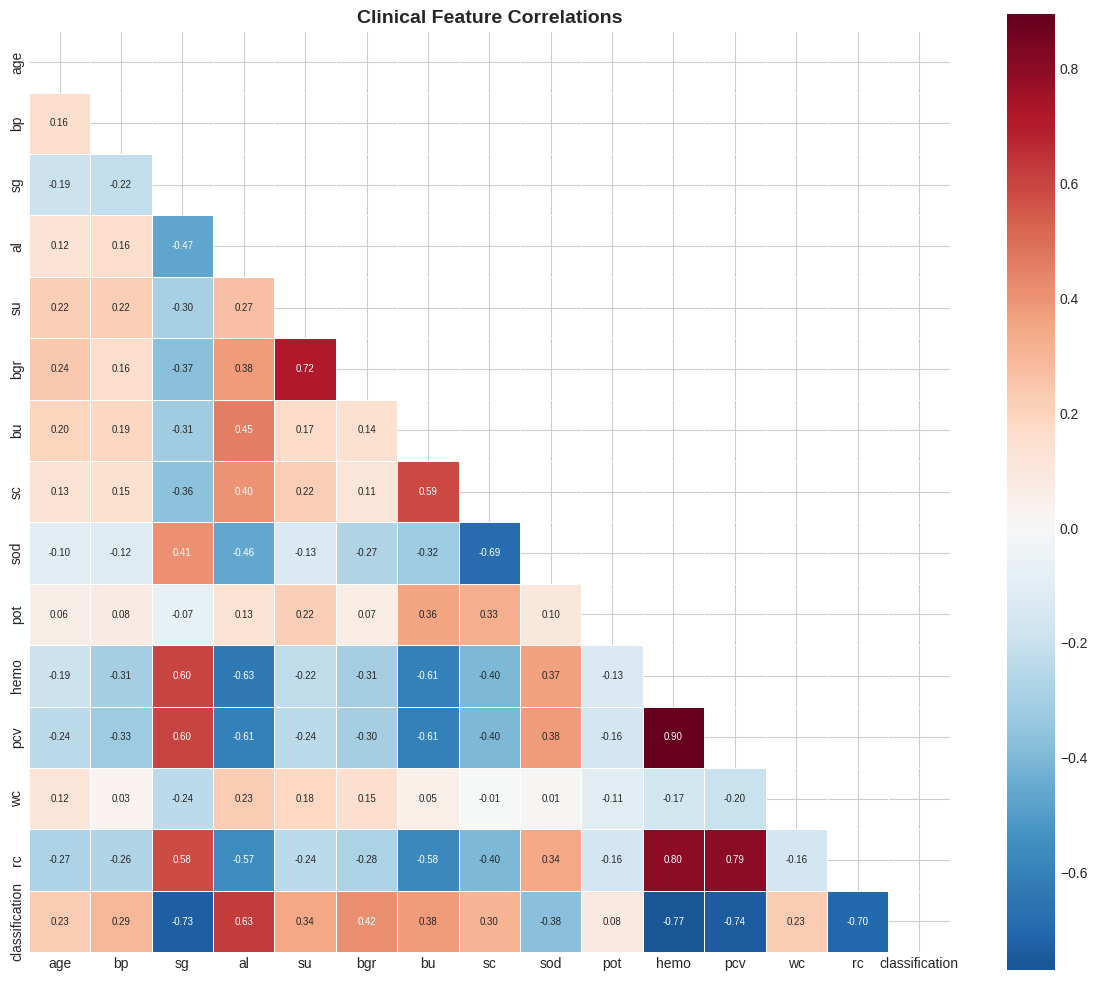

Top correlations with CKD:
  hemo                      -0.7689
  pcv                       -0.7414
  sg                        -0.7322
  rc                        -0.6991
  al                        +0.6271
  bgr                       +0.4197
  bu                        +0.3806
  sod                       -0.3757
  su                        +0.3441
  sc                        +0.3000


In [8]:
if len(numeric_cols) > 1:
    corr_cols = numeric_cols[:15] + [target_col]
    corr = df[corr_cols].corr()
    fig, ax = plt.subplots(figsize=(12, 10))
    mask = np.triu(np.ones_like(corr, dtype=bool))
    sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdBu_r', center=0,
                square=True, linewidths=0.5, ax=ax, annot_kws={'size': 7})
    ax.set_title('Clinical Feature Correlations', fontsize=14, fontweight='bold')
    plt.tight_layout(); plt.savefig('correlation_heatmap.png', dpi=150, bbox_inches='tight'); plt.show()
    target_corr = corr[target_col].drop(target_col).abs().sort_values(ascending=False)
    print("Top correlations with CKD:")
    for feat, val in target_corr.head(10).items():
        direction = "+" if corr.loc[feat, target_col] > 0 else "-"
        print(f"  {feat:25s} {direction}{val:.4f}")


## 4. Feature Engineering & Preprocessing

In [9]:
df_model = df.copy()

# Drop ID column if present
drop_cols = [c for c in df_model.columns if c.lower() in ['id', 'index', 'unnamed: 0']]
if drop_cols:
    df_model.drop(columns=drop_cols, inplace=True)

# Clean and encode categoricals
le_dict = {}
for col in df_model.select_dtypes(include=['object']).columns:
    if col != target_col:
        df_model[col] = df_model[col].str.strip() if df_model[col].dtype == 'object' else df_model[col]
        le = LabelEncoder()
        df_model[col] = df_model[col].fillna('__MISSING__')
        df_model[col] = le.fit_transform(df_model[col].astype(str))
        le_dict[col] = le
        print(f"  Encoded '{col}': {len(le.classes_)} classes")

X = df_model.drop(columns=[target_col])
y = df_model[target_col].values

# Impute missing values
null_counts = X.isnull().sum()
if null_counts.sum() > 0:
    print(f"\nImputing {null_counts.sum()} missing values with median...")
    X = X.fillna(X.median())

print(f"\nFeature matrix: {X.shape}")
print(f"Target: {dict(zip(*np.unique(y, return_counts=True)))}")


  Encoded 'rbc': 3 classes
  Encoded 'pc': 3 classes
  Encoded 'pcc': 3 classes
  Encoded 'ba': 3 classes
  Encoded 'htn': 3 classes
  Encoded 'dm': 3 classes
  Encoded 'cad': 3 classes
  Encoded 'appet': 3 classes
  Encoded 'pe': 3 classes
  Encoded 'ane': 3 classes

Imputing 778 missing values with median...

Feature matrix: (400, 24)
Target: {np.int64(0): np.int64(150), np.int64(1): np.int64(250)}


## 5. Model Training & Cross-Validation

In [10]:
try:
    from xgboost import XGBClassifier
    print("XGBoost loaded")
except ImportError:
    XGBClassifier = None
try:
    from lightgbm import LGBMClassifier
    print("LightGBM loaded")
except ImportError:
    LGBMClassifier = None


XGBoost loaded
LightGBM loaded


In [11]:
models = {
    'Logistic Regression': LogisticRegression(max_iter=2000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
}
if XGBClassifier is not None:
    models['XGBoost'] = XGBClassifier(n_estimators=100, random_state=42, eval_metric='logloss',
                                       use_label_encoder=False, verbosity=0, n_jobs=-1)
if LGBMClassifier is not None:
    models['LightGBM'] = LGBMClassifier(n_estimators=100, random_state=42, verbose=-1,
                                          n_jobs=-1, force_col_wise=True)

skf = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
X_arr = X.values
results = {}

for model_name, model in models.items():
    print(f"\n{'='*60}\nTraining: {model_name}\n{'='*60}")
    fold_acc, fold_f1, fold_auc, fold_prec, fold_rec, fold_brier = [], [], [], [], [], []
    fold_preds = np.zeros(len(y), dtype=int)
    fold_proba = np.zeros(len(y), dtype=float)
    t_start = time.time()
    for fold_idx, (train_idx, val_idx) in enumerate(skf.split(X_arr, y)):
        X_train, X_val = X_arr[train_idx], X_arr[val_idx]
        y_train, y_val = y[train_idx], y[val_idx]
        model_clone = type(model)(**model.get_params())
        model_clone.fit(X_train, y_train)
        y_pred = model_clone.predict(X_val)
        y_prob = model_clone.predict_proba(X_val)[:, 1]
        fold_preds[val_idx] = y_pred; fold_proba[val_idx] = y_prob
        acc = accuracy_score(y_val, y_pred); f1 = f1_score(y_val, y_pred)
        auc = roc_auc_score(y_val, y_prob)
        prec = precision_score(y_val, y_pred, zero_division=0)
        rec = recall_score(y_val, y_pred, zero_division=0)
        brier = brier_score_loss(y_val, y_prob)
        fold_acc.append(acc); fold_f1.append(f1); fold_auc.append(auc)
        fold_prec.append(prec); fold_rec.append(rec); fold_brier.append(brier)
        print(f"  Fold {fold_idx+1}: Acc={acc:.4f}  F1={f1:.4f}  AUC={auc:.4f}")
    elapsed = time.time() - t_start
    results[model_name] = {
        'accuracy_mean': np.mean(fold_acc), 'accuracy_std': np.std(fold_acc),
        'f1_mean': np.mean(fold_f1), 'f1_std': np.std(fold_f1),
        'auc_mean': np.mean(fold_auc), 'auc_std': np.std(fold_auc),
        'precision_mean': np.mean(fold_prec), 'recall_mean': np.mean(fold_rec),
        'brier_mean': np.mean(fold_brier), 'time': elapsed,
        'oof_preds': fold_preds, 'oof_proba': fold_proba}
    print(f"  -- Acc: {np.mean(fold_acc):.4f}  F1: {np.mean(fold_f1):.4f}  AUC: {np.mean(fold_auc):.4f}  Time: {elapsed:.2f}s")



Training: Logistic Regression
  Fold 1: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: Acc=0.9850  F1=0.9878  AUC=0.9971
  Fold 3: Acc=0.9774  F1=0.9818  AUC=0.9988
  -- Acc: 0.9875  F1: 0.9899  AUC: 0.9986  Time: 0.85s

Training: Random Forest
  Fold 1: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: Acc=0.9925  F1=0.9940  AUC=1.0000
  Fold 3: Acc=1.0000  F1=1.0000  AUC=1.0000
  -- Acc: 0.9975  F1: 0.9980  AUC: 1.0000  Time: 0.78s

Training: XGBoost
  Fold 1: Acc=0.9925  F1=0.9941  AUC=1.0000
  Fold 2: Acc=0.9699  F1=0.9759  AUC=0.9981
  Fold 3: Acc=0.9925  F1=0.9939  AUC=0.9998
  -- Acc: 0.9850  F1: 0.9880  AUC: 0.9993  Time: 0.24s

Training: LightGBM
  Fold 1: Acc=1.0000  F1=1.0000  AUC=1.0000
  Fold 2: Acc=0.9925  F1=0.9939  AUC=1.0000
  Fold 3: Acc=1.0000  F1=1.0000  AUC=1.0000
  -- Acc: 0.9975  F1: 0.9980  AUC: 1.0000  Time: 0.20s


## 6. Model Comparison & Selection

In [12]:
summary_rows = []
for mn, res in results.items():
    summary_rows.append({'Model': mn,
        'Accuracy': f"{res['accuracy_mean']:.4f} +/- {res['accuracy_std']:.4f}",
        'F1': f"{res['f1_mean']:.4f} +/- {res['f1_std']:.4f}",
        'ROC-AUC': f"{res['auc_mean']:.4f} +/- {res['auc_std']:.4f}",
        'Brier': f"{res['brier_mean']:.4f}", 'Time': f"{res['time']:.2f}s",
        'AUC_val': res['auc_mean']})
summary_df = pd.DataFrame(summary_rows).sort_values('AUC_val', ascending=False)
best_model_name = summary_df.iloc[0]['Model']
print("MODEL COMPARISON")
print("=" * 100)
print(summary_df[['Model', 'Accuracy', 'F1', 'ROC-AUC', 'Brier', 'Time']].to_string(index=False))
print("=" * 100)
print(f"\nBest model: {best_model_name}")


MODEL COMPARISON
              Model          Accuracy                F1           ROC-AUC  Brier  Time
      Random Forest 0.9975 +/- 0.0035 0.9980 +/- 0.0028 1.0000 +/- 0.0000 0.0076 0.78s
           LightGBM 0.9975 +/- 0.0035 0.9980 +/- 0.0029 1.0000 +/- 0.0000 0.0018 0.20s
            XGBoost 0.9850 +/- 0.0106 0.9880 +/- 0.0085 0.9993 +/- 0.0009 0.0096 0.24s
Logistic Regression 0.9875 +/- 0.0094 0.9899 +/- 0.0076 0.9986 +/- 0.0012 0.0091 0.85s

Best model: Random Forest


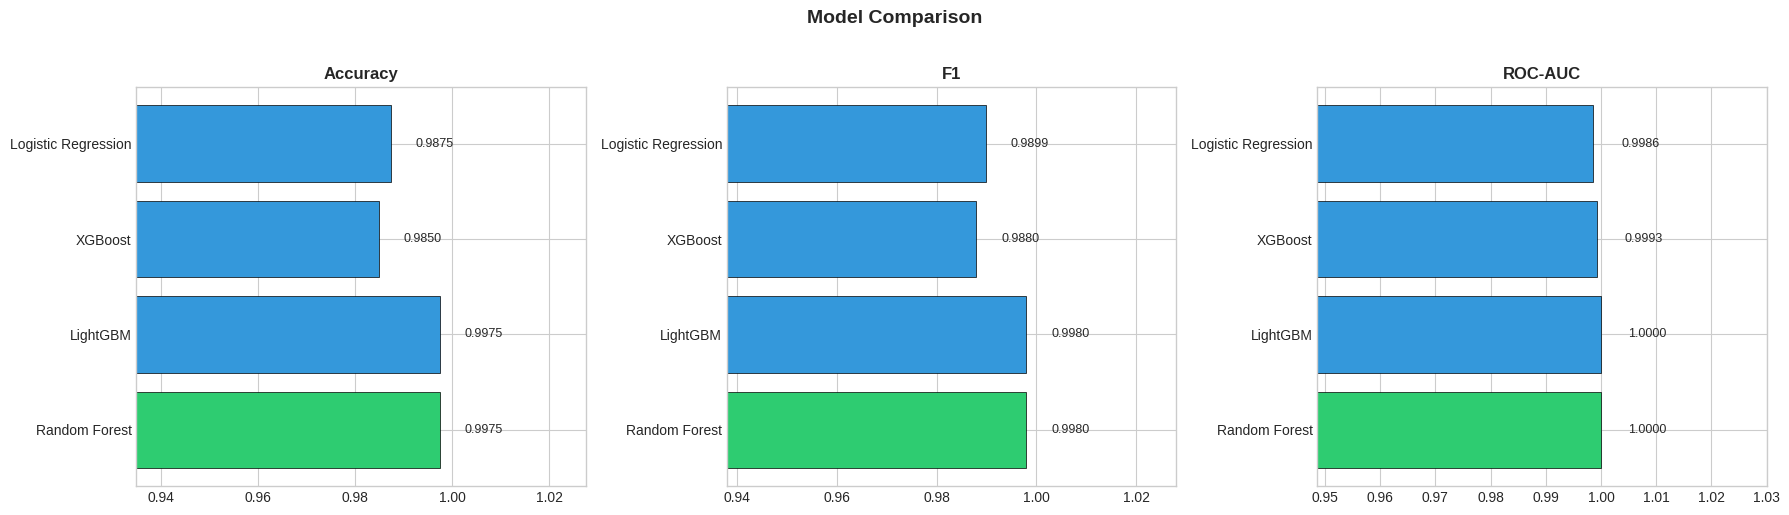

In [13]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
model_names = [r['Model'] for _, r in summary_df.iterrows()]
colors = ['#2ecc71' if m == best_model_name else '#3498db' for m in model_names]
for ax, metric, title in zip(axes, ['accuracy_mean', 'f1_mean', 'auc_mean'], ['Accuracy', 'F1', 'ROC-AUC']):
    vals = [results[m][metric] for m in model_names]
    ax.barh(model_names, vals, color=colors, edgecolor='black', linewidth=0.5)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlim(min(vals) - 0.05, max(vals) + 0.03)
    for i, v in enumerate(vals):
        ax.text(v + 0.005, i, f'{v:.4f}', va='center', fontsize=9)
plt.suptitle('Model Comparison', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout(); plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight'); plt.show()


## 7. Error Analysis & Threshold Tuning

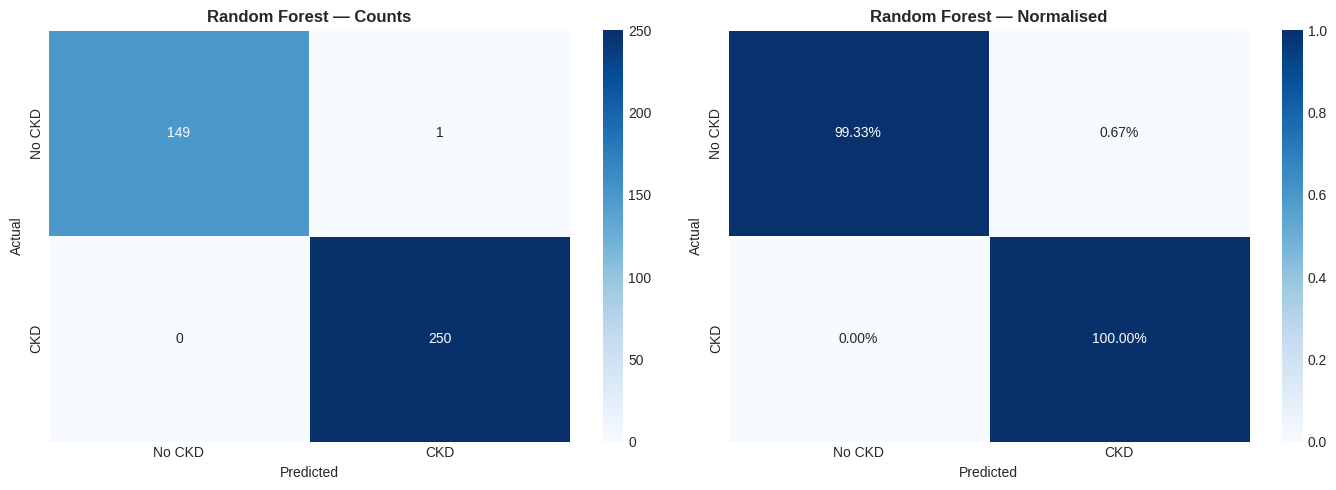


              precision    recall  f1-score   support

      No CKD       1.00      0.99      1.00       150
         CKD       1.00      1.00      1.00       250

    accuracy                           1.00       400
   macro avg       1.00      1.00      1.00       400
weighted avg       1.00      1.00      1.00       400



In [14]:
best_preds = results[best_model_name]['oof_preds']
best_proba = results[best_model_name]['oof_proba']
cm = confusion_matrix(y, best_preds)
cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cm_labels = ['No CKD', 'CKD']
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[0], linewidths=0.5)
axes[0].set_title(f'{best_model_name} — Counts', fontweight='bold')
axes[0].set_ylabel('Actual'); axes[0].set_xlabel('Predicted')
sns.heatmap(cm_norm, annot=True, fmt='.2%', cmap='Blues', xticklabels=cm_labels, yticklabels=cm_labels, ax=axes[1], linewidths=0.5)
axes[1].set_title(f'{best_model_name} — Normalised', fontweight='bold')
axes[1].set_ylabel('Actual'); axes[1].set_xlabel('Predicted')
plt.tight_layout(); plt.savefig('confusion_matrix.png', dpi=150, bbox_inches='tight'); plt.show()
print(f"\n{classification_report(y, best_preds, target_names=cm_labels)}")


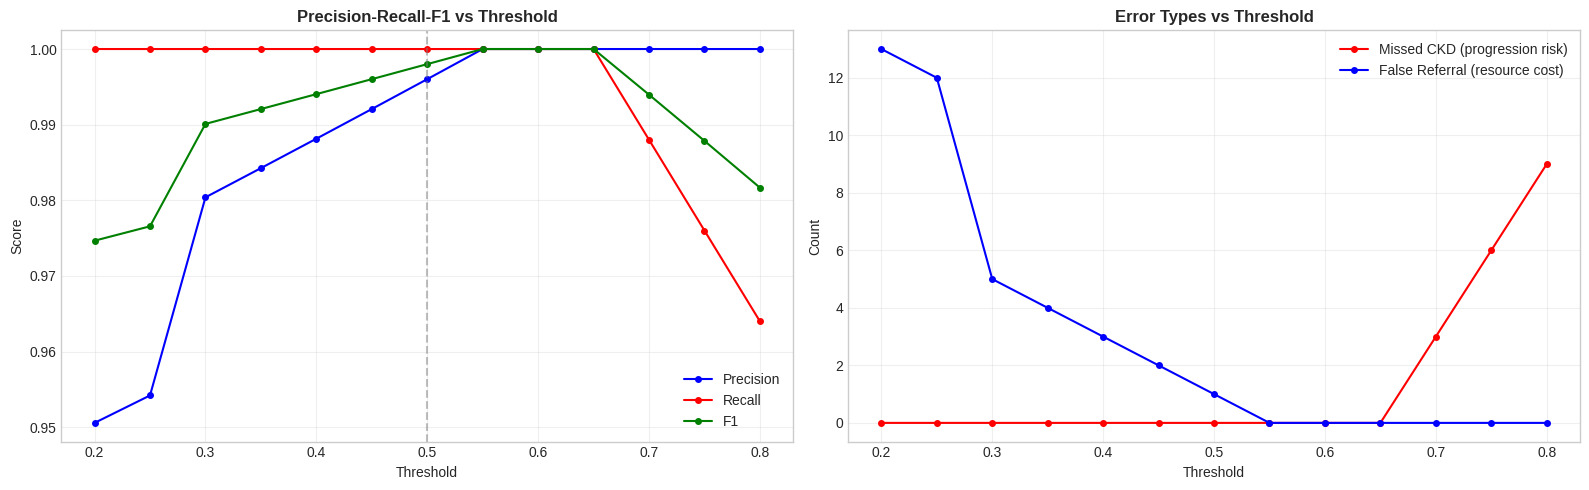


Optimal threshold (F1): 0.55


In [15]:
thresholds = np.arange(0.20, 0.80, 0.05)
thresh_results = []
for thresh in thresholds:
    y_t = (best_proba >= thresh).astype(int)
    thresh_results.append({'Threshold': thresh,
        'Precision': precision_score(y, y_t, zero_division=0),
        'Recall': recall_score(y, y_t, zero_division=0),
        'F1': f1_score(y, y_t, zero_division=0),
        'Missed CKD (FN)': ((y == 1) & (y_t == 0)).sum(),
        'False Referral (FP)': ((y == 0) & (y_t == 1)).sum()})
thresh_df = pd.DataFrame(thresh_results)
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
axes[0].plot(thresh_df['Threshold'], thresh_df['Precision'], 'b-o', ms=4, label='Precision')
axes[0].plot(thresh_df['Threshold'], thresh_df['Recall'], 'r-o', ms=4, label='Recall')
axes[0].plot(thresh_df['Threshold'], thresh_df['F1'], 'g-o', ms=4, label='F1')
axes[0].axvline(x=0.5, color='gray', linestyle='--', alpha=0.5)
axes[0].set_xlabel('Threshold'); axes[0].set_ylabel('Score')
axes[0].set_title('Precision-Recall-F1 vs Threshold', fontweight='bold')
axes[0].legend(); axes[0].grid(True, alpha=0.3)
axes[1].plot(thresh_df['Threshold'], thresh_df['Missed CKD (FN)'], 'r-o', ms=4, label='Missed CKD (progression risk)')
axes[1].plot(thresh_df['Threshold'], thresh_df['False Referral (FP)'], 'b-o', ms=4, label='False Referral (resource cost)')
axes[1].set_xlabel('Threshold'); axes[1].set_ylabel('Count')
axes[1].set_title('Error Types vs Threshold', fontweight='bold')
axes[1].legend(); axes[1].grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('threshold_tuning.png', dpi=150, bbox_inches='tight'); plt.show()
best_f1_idx = thresh_df['F1'].idxmax()
optimal_thresh = thresh_df.loc[best_f1_idx, 'Threshold']
print(f"\nOptimal threshold (F1): {optimal_thresh:.2f}")


## 8. Feature Importance & Policy Insights

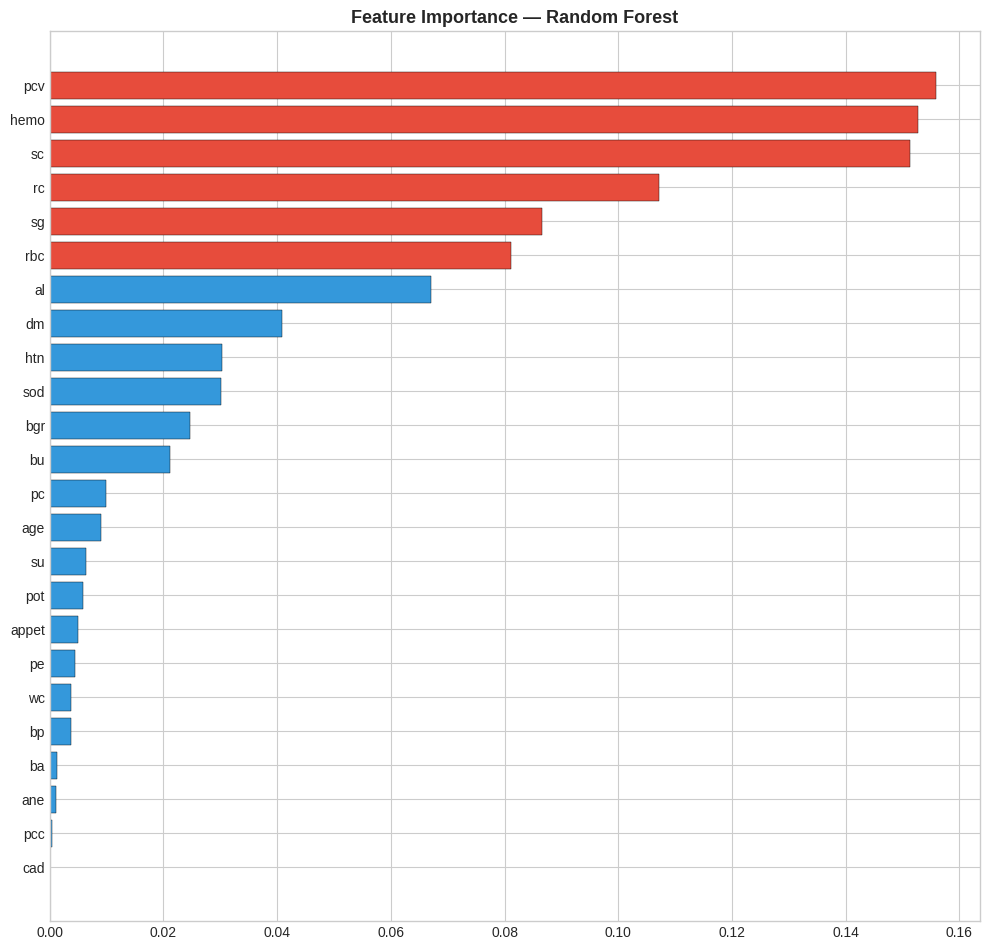

TOP 5 CLINICAL PREDICTORS
  pcv                        0.1558
  hemo                       0.1528
  sc                         0.1512
  rc                         0.1072
  sg                         0.0866


In [16]:
tree_models = {k: v for k, v in models.items() if k != 'Logistic Regression'}
if tree_models:
    best_tree = max(tree_models.keys(), key=lambda m: results[m]['auc_mean'])
    full_model = type(models[best_tree])(**models[best_tree].get_params())
    full_model.fit(X_arr, y)
    feat_imp = pd.DataFrame({'Feature': X.columns, 'Importance': full_model.feature_importances_}).sort_values('Importance', ascending=True)
    fig, ax = plt.subplots(figsize=(10, max(6, len(feat_imp) * 0.4)))
    colors_imp = ['#e74c3c' if imp > feat_imp['Importance'].quantile(0.75) else '#3498db' for imp in feat_imp['Importance']]
    ax.barh(feat_imp['Feature'], feat_imp['Importance'], color=colors_imp, edgecolor='black', linewidth=0.3)
    ax.set_title(f'Feature Importance — {best_tree}', fontsize=13, fontweight='bold')
    plt.tight_layout(); plt.savefig('feature_importance.png', dpi=150, bbox_inches='tight'); plt.show()
    top5 = feat_imp.tail(5).iloc[::-1]
    print("TOP 5 CLINICAL PREDICTORS")
    print("=" * 50)
    for _, row in top5.iterrows():
        print(f"  {row['Feature']:25s}  {row['Importance']:.4f}")


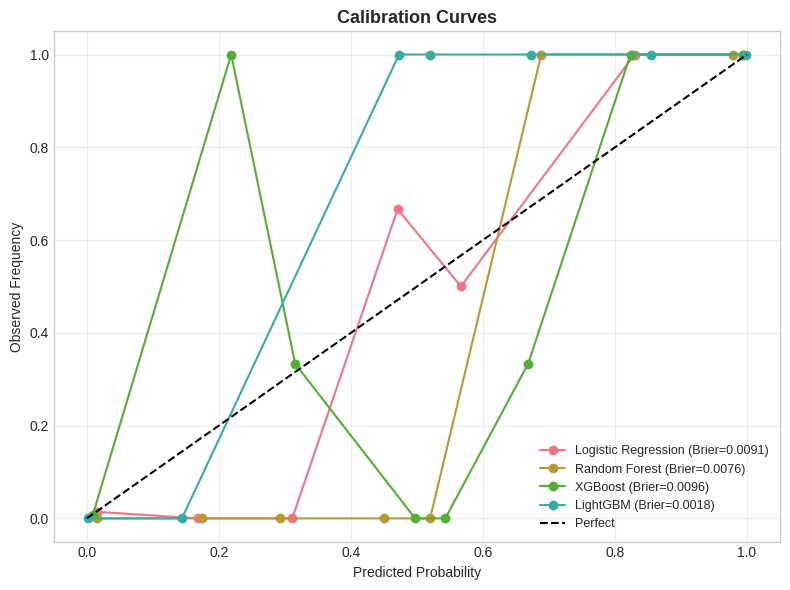

In [17]:
fig, ax = plt.subplots(figsize=(8, 6))
for mn in results:
    prob_true, prob_pred = calibration_curve(y, results[mn]['oof_proba'], n_bins=8, strategy='uniform')
    ax.plot(prob_pred, prob_true, 'o-', label=f"{mn} (Brier={results[mn]['brier_mean']:.4f})")
ax.plot([0, 1], [0, 1], 'k--', label='Perfect')
ax.set_xlabel('Predicted Probability'); ax.set_ylabel('Observed Frequency')
ax.set_title('Calibration Curves', fontsize=13, fontweight='bold')
ax.legend(fontsize=9); ax.grid(True, alpha=0.3)
plt.tight_layout(); plt.savefig('calibration_curves.png', dpi=150, bbox_inches='tight'); plt.show()


## 9. Deployment Readiness & Production Considerations

In [18]:
best_res = results[best_model_name]
print("=" * 60)
print("DEPLOYMENT READINESS SUMMARY")
print("=" * 60)
print(f"  Recommended model:    {best_model_name}")
print(f"  ROC-AUC:              {best_res['auc_mean']:.4f}")
print(f"  F1:                   {best_res['f1_mean']:.4f}")
print(f"  Precision:            {best_res['precision_mean']:.4f}")
print(f"  Recall:               {best_res['recall_mean']:.4f}")
print(f"  Brier Score:          {best_res['brier_mean']:.4f}")
print(f"  Training time:        {best_res['time']:.1f}s")
print(f"  Feature count:        {X.shape[1]}")
print(f"  Dataset rows:         {len(y):,}")
print(f"  CV strategy:          3-fold Stratified")
print(f"  Optimal threshold:    {optimal_thresh:.2f}")
print("=" * 60)
checks = {
    'AUC > 0.80': best_res['auc_mean'] > 0.80,
    'F1 > 0.70': best_res['f1_mean'] > 0.70,
    'Brier < 0.20': best_res['brier_mean'] < 0.20,
    'Training time < 60s': best_res['time'] < 60,
    'Cross-validated': True,
    'Threshold tuning done': True,
    'Calibration assessed': True,
}
print("\nPRODUCTION READINESS CHECKLIST")
print("-" * 50)
all_pass = True
for check, passed in checks.items():
    status = "pass" if passed else "FAIL"
    if not passed: all_pass = False
    print(f"  [{status:4s}] {check}")
print("-" * 50)
print("  MODEL APPROVED FOR PILOT DEPLOYMENT" if all_pass else "  SOME CHECKS FAILED")


DEPLOYMENT READINESS SUMMARY
  Recommended model:    Random Forest
  ROC-AUC:              1.0000
  F1:                   0.9980
  Precision:            0.9960
  Recall:               1.0000
  Brier Score:          0.0076
  Training time:        0.8s
  Feature count:        24
  Dataset rows:         400
  CV strategy:          3-fold Stratified
  Optimal threshold:    0.55

PRODUCTION READINESS CHECKLIST
--------------------------------------------------
  [pass] AUC > 0.80
  [pass] F1 > 0.70
  [pass] Brier < 0.20
  [pass] Training time < 60s
  [pass] Cross-validated
  [pass] Threshold tuning done
  [pass] Calibration assessed
--------------------------------------------------
  MODEL APPROVED FOR PILOT DEPLOYMENT


In [19]:
print("""
============================================================
PRODUCTION INTEGRATION ARCHITECTURE
============================================================

1. DATA PIPELINE
   Source: GP pathology systems, My Health Record, ANZDATA registry
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (eGFR, ACR, electrolytes, BP)
   Schedule: Real-time at pathology result receipt + quarterly screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) at pathology result notification
   Output: CKD risk score + stage estimate + recommended action
   Batch: Quarterly PHN renal risk stratification by practice

3. INTEGRATION POINTS
   GP desktop: CKD risk alert in Best Practice / Medical Director
   Pathology: Auto-flag high-risk eGFR/ACR results
   Medicare: Trigger CDM items (721/723) for CKD management plans
   Nephrology: Auto-generate referral for stage 3b+ predictions
   Kidney Health Australia: Population screening program support

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device classification
   Validation: Against KDIGO CKD staging as gold standard
   Explainability: Top pathology drivers shown to GP
   Equity: Monitor Indigenous, rural/remote, CALD populations
   RACGP: Alignment with kidney health screening guidelines

5. MONITORING & RETRAINING
   Drift: PSI on pathology distributions quarterly
   Performance: AUC on confirmed nephrology diagnoses (6-month lag)
   Retraining: Annual with confirmed CKD staging outcomes
   Guidelines: Recalibrate when KDIGO/KHA guidelines update
   Population: Adjust for aging population demographics

============================================================
""")



PRODUCTION INTEGRATION ARCHITECTURE

1. DATA PIPELINE
   Source: GP pathology systems, My Health Record, ANZDATA registry
   Ingestion: HL7 FHIR API -> Azure Data Factory -> Fabric Lakehouse
   Feature store: Fabric gold layer (eGFR, ACR, electrolytes, BP)
   Schedule: Real-time at pathology result receipt + quarterly screening

2. MODEL SERVING
   Framework: MLflow model registry
   Endpoint: Real-time (<200ms) at pathology result notification
   Output: CKD risk score + stage estimate + recommended action
   Batch: Quarterly PHN renal risk stratification by practice

3. INTEGRATION POINTS
   GP desktop: CKD risk alert in Best Practice / Medical Director
   Pathology: Auto-flag high-risk eGFR/ACR results
   Medicare: Trigger CDM items (721/723) for CKD management plans
   Nephrology: Auto-generate referral for stage 3b+ predictions
   Kidney Health Australia: Population screening program support

4. CLINICAL GOVERNANCE
   TGA: Software as Medical Device classification
   Validation: 